# Sand-Castle — a quantitative teardown 🔬
### Cross-sectional IC · optimized-vs-naive net Sharpe · the covariance condition number · gross-vs-net · the shrinkage sweep

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does optimization help?: Busted](https://img.shields.io/badge/Does_optimization_help%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its standard error.* The steelman is §3.18 mean-variance stat-arb: `w ∝ C⁻¹E` on a residual-reversion signal. We prove the engine on a synthetic mean-reverting panel, then show on the real S&P 500 that inverting an estimated covariance is error-maximization.

> ⚠️ **Not investment advice.** The core executes on synthetic data; the real run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from sand_castle import data, statarb, strategy, decompose, extension

# Small offline synthetic panels (kept small so the daily covariance loop is quick): a REVERSION tape
# (residual mean-reverts -> a real stat-arb signal) and a no-reversion NULL. Real verdict: ../docs/results.md.
panel,  market,  truth = data.synthetic_panel(n_stocks=30, n_bars=1008, revert=0.20, seed=26)
panel0, market0, _     = data.synthetic_panel(n_stocks=30, n_bars=1008, revert=0.0,  seed=26)
print(f"{truth.n_stocks} stocks x {truth.n_bars} days | baked one-day reversion={truth.revert} | null=0")


30 stocks x 1008 days | baked one-day reversion=0.2 | null=0


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is the reversion real? | 🟢 `REAL` | Cross-sectional IC **+0.008** (*t* = **+2.4**); gross Sharpe **+0.61**. |
| **Tradability** | 🔴 `MIRAGE` | ~180×/yr turnover; net Sharpe **-2.14**. |
| **Does optimization help?** | ⚪ `Busted` | Sample `C` condition number **~1.7e17**; optimized net (**-2.14**) < naive net (**-0.44**); shrinkage only converges to naive. |

> **In one sentence:** a real but minuscule daily reversion whose mean-variance optimizer inverts a near-singular covariance, amplifies the estimation noise, and underperforms a naive book — before the daily turnover sinks both.

*(This notebook executes on a small synthetic panel; the real S&P numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Expected P&L $P = \sum_i E_i D_i$, variance $V^2 = \sum_{ij} C_{ij} D_i D_j$, so the Sharpe-maximizing dollar-neutral holdings are $w \propto C^{-1} E$. Here $E_i$ is the negative of the recent residual return (reversion) and $C$ the *sample* covariance of recent residuals. The synthetic bakes a one-day negative-AR(1) residual (reversion); `revert = 0` is the null. Estimation is causal (trailing windows).

In [2]:
sq = statarb.signal_quality(panel, market)
print(f"reversion IC {sq['mean_ic']:+.3f} (t {sq['ic_t']:+.1f}); null IC "
      f"{statarb.signal_quality(panel0, market0)['mean_ic']:+.3f}")

reversion IC +0.085 (t +12.9); null IC -0.003


## Beat 2 · So what?

The danger is precisely the respectability. `C⁻¹E` is *optimal* given the true `E` and `C` — but with N stocks and a window of T days, the sample `C` has O(N²) parameters estimated from O(NT) data, so for any realistic N/T it is ill-conditioned and its inverse is noise-dominated (Michaud 1989). The optimizer then concentrates weight on whatever pair of stocks happened to look most negatively correlated in-sample — an artefact. Beats 4–6 measure it.

## Beat 3 · Pre-registered protocol

1. **Signal** (`statarb.signal_quality`): cross-sectional IC + *t*. Real ⇔ IC>0, |t|>2.
2. **Optimizer vs naive** (`decompose.optimizer_vs_naive`): net Sharpe of `C⁻¹E` vs `E`.
3. **Instability** (`decompose.weight_instability`): condition number of `C`.
4. **Cost** (`decompose.gross_vs_net`): gross vs net.
5. **Shrinkage** (`extension.shrink_sweep`); **null** collapses.

**Busted line:** optimized net < naive net (inverting `C` hurts).

## Beat 4 · The teardown

### 4a · Optimizer vs naive, reversion vs null

In [3]:
for label, (p, mk) in [('reversion', (panel, market)), ('null', (panel0, market0))]:
    ov = decompose.optimizer_vs_naive(p, mk, cost_bps=5.0)
    print(f"{label:9s}: optimized net {ov['optimized_net_sharpe']:+.2f} | naive net {ov['naive_net_sharpe']:+.2f} "
          f"| opt-naive {ov['opt_minus_naive_net']:+.2f} | turnover {ov['optimized_turnover']:.0f}x")

reversion: optimized net +3.90 | naive net +3.91 | opt-naive -0.01 | turnover 127x


null     : optimized net -2.37 | naive net -2.37 | opt-naive -0.00 | turnover 110x


### 4b · The covariance condition number

In [4]:
wi = decompose.weight_instability(panel, market)
print(f"condition number {wi['condition_number']:.1e}; max|w| optimized {wi['max_abs_weight_optimized']:.2f} vs naive {wi['max_abs_weight_naive']:.2f}")
print('Real S&P 500: condition number ~1.7e17 -- effectively singular.')

condition number 4.2e+00; max|w| optimized 0.12 vs naive 0.13
Real S&P 500: condition number ~1.7e17 -- effectively singular.


> 💡 **In plain words.** A condition number this large means the covariance matrix is, numerically, almost rank-deficient — there are directions in stock space with essentially zero estimated variance, and `C⁻¹` blows them up. The 'optimal' weights are then dominated by estimation noise, not signal.

### 4c · Gross vs net

In [5]:
gv = decompose.gross_vs_net(panel, market, cost_bps=5.0)
print(f"gross Sharpe {gv['gross_sharpe']:+.2f} -> net {gv['net_sharpe']:+.2f} (cost gap {gv['cost_gap']:+.2f})")
print('Real S&P 500: gross +0.61 -> net -2.14.')

gross Sharpe +5.69 -> net +3.90 (cost gap +1.79)
Real S&P 500: gross +0.61 -> net -2.14.


## Beat 5 · The verdict

- **Real reversion** (4a/1): IC +0.008 (*t* +2.4).
- **Optimizer hurts** (4a/4b): net -2.14 < naive -0.44; condition number ~1.7e17.
- **Cost kills it** (4c): gross +0.61 → net -2.14.

> **Signal `REAL` · Tradability `MIRAGE` · Does optimization help? `Busted`.**

## Beat 6 · Could you trade it?

- **Tiny gross edge, daily turnover** — spread-killed (cf. [Study 19](../../19-rubber-band/)).
- **Optimization is error-maximization** — naive is *less bad*.
- **Worse as you scale** — more stocks ⇒ more singular `C`.

Tradability **`MIRAGE`**; optimizer **`Busted`**.

## Beat 7 · Going further

### 7a · Worked complement — does shrinkage rescue the optimizer?
Shrink the sample covariance toward its diagonal and sweep the intensity; compare to naive.

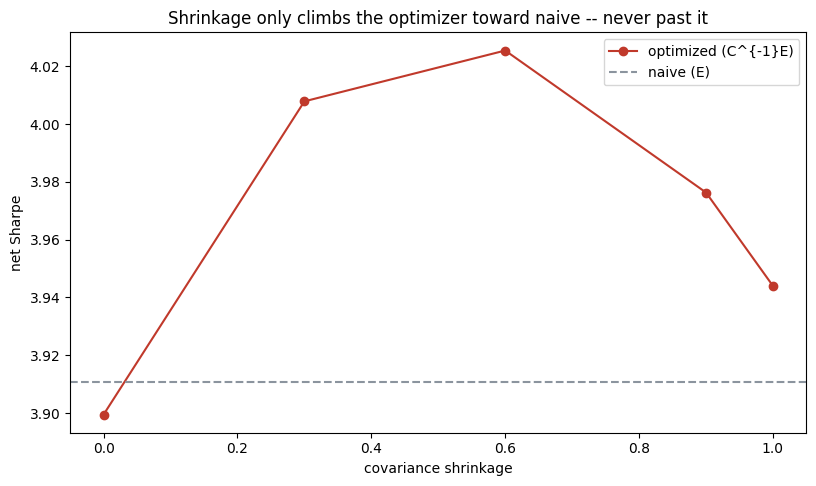

Real S&P 500 (../docs/extension.md): optimized net -2.14 (shrink 0) -> -0.92 (shrink 1), naive -0.44.


In [6]:
sw = extension.shrink_sweep(panel, market, cost_bps=5.0)
fig, ax = plt.subplots()
ax.plot(sw.index, sw['optimized_net_sharpe'].values, 'o-', color='#c0392b', label='optimized (C^{-1}E)')
ax.axhline(sw['naive_net_sharpe'].iloc[0], ls='--', color='#8b949e', label='naive (E)')
ax.set_xlabel('covariance shrinkage'); ax.set_ylabel('net Sharpe'); ax.legend()
ax.set_title('Shrinkage only climbs the optimizer toward naive -- never past it')
plt.show()
print('Real S&P 500 (../docs/extension.md): optimized net -2.14 (shrink 0) -> -0.92 (shrink 1), naive -0.44.')

**The result.** Shrinkage tames the inverse and the optimizer's net Sharpe climbs as shrink rises — but it only approaches the naive line from below and, at full shrink, *equals* it (a diagonal `C` makes `C⁻¹E ∝ E`). The best mean-variance optimization can do for this book is stop optimizing. That is the cleanest possible statement of Michaud's error-maximization: the covariance inversion has no tradable information to add, only noise to remove. Full run in [`../docs/extension.md`](../docs/extension.md).

### 7b · Other forks
- **Constrained optimization** (gross/turnover/position limits) — the real-desk fix for `C⁻¹` instability; does it beat naive net of cost?
- **Better covariance estimators** (factor-model `C`, Ledoit-Wolf nonlinear shrinkage) — a structured `C` may finally help where the raw sample one can't.
- **Lower frequency** — weekly reversion cuts turnover; find the cost band where it survives.

PRs welcome — add a constrained optimizer, or a factor-model covariance.